# 1、使用FUNCTION_CALL模式

In [1]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 提供提示词模板（以ChatPromptTemplate为例）
prompt_template = ChatPromptTemplate.from_messages([
    ("system","你是一个乐于助人的ai助手，根据用户的提问，必要时调用Search工具，使用互联网检索数据"),
    ("human","{input}"),
    ("system","{agent_scratchpad}"),
    # ("placeholder","{agent_scratchpad}")
])

# 获取Agent的实例：create_tool_calling_agent()
agent = create_tool_calling_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询今天北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='北京今天天气晴，温度20℃。', additional_kwargs={})


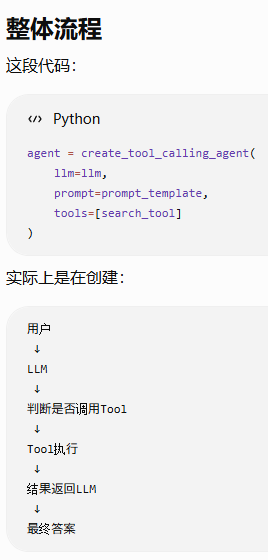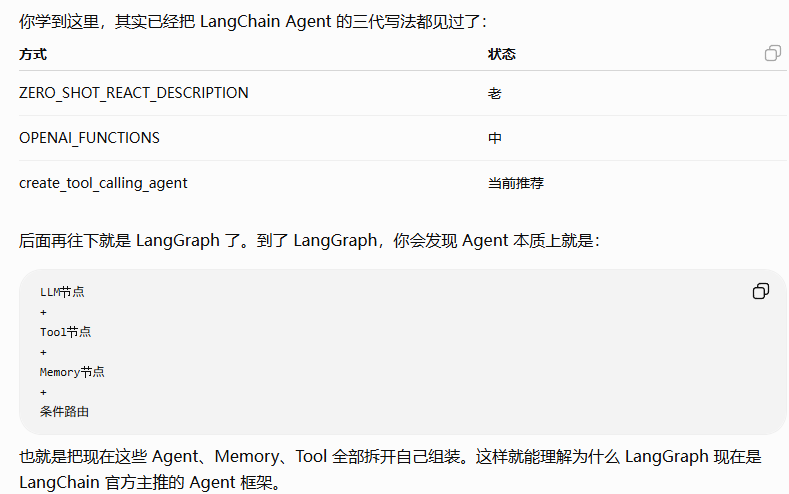

注意：agent_scratchpad必须声明，它用于存储和传递Agent的思考过程。比如，在调用链式工具时（如先搜索天气再推荐行程），`agent_scratchpad` 保留所有历史步骤，避免上下文丢失。format方法会将intermediate_steps转换为特定格式的字符串，并赋值给agent_scratchpad变量。如果不传递intermediate_steps参数，会导致KeyError: 'intermediate_steps'错误。

# 2、使用ReAct模式

举例1：使用PromptTemplate实现

In [2]:
from langchain.agents import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 提供提示词模板（以PromptTemplate为例）
template = """
Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}"""
prompt_template = PromptTemplate.from_template(
    template=template,
)

# 获取Agent的实例：create_react_agent()
agent = create_react_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询今天北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='北京市当前天气情况为多云，温度21摄氏度。', additional_kwargs={})


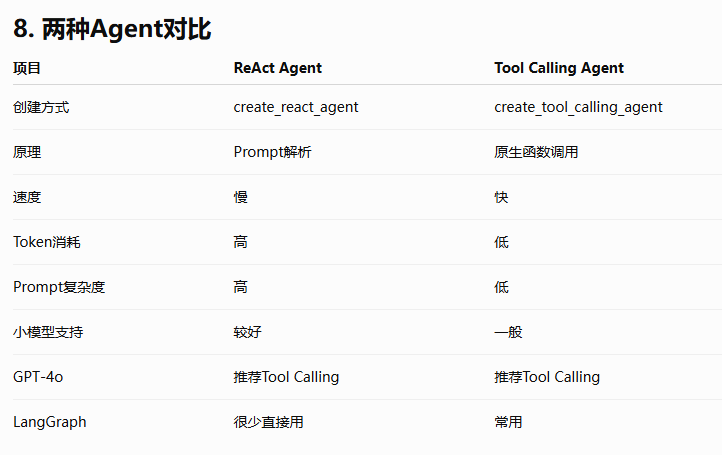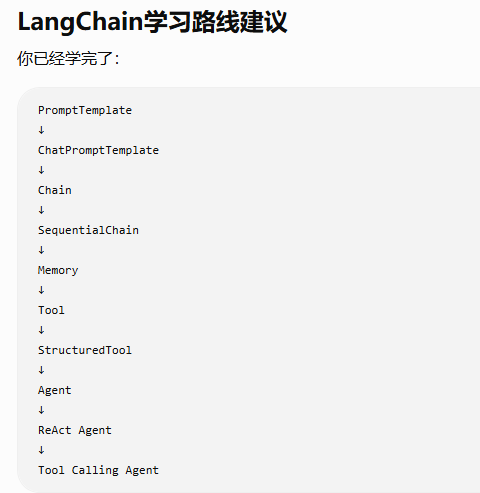

上述的举例1也可以改写为：

In [3]:
from langchain import hub
from langchain.agents import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 使用LangChain Hub中的官方ReAct提示模板
prompt_template = hub.pull("hwchase17/react")


# 获取Agent的实例：create_react_agent()
agent = create_react_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询今天北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='Mock response (qwen2.5-coder:1.5b, e29712cbf9305066): 查询今天北京的天气情况\n\n\n[Search]\nLocal Tavily stub: 查询今天北京的天气情况', additional_kwargs={})


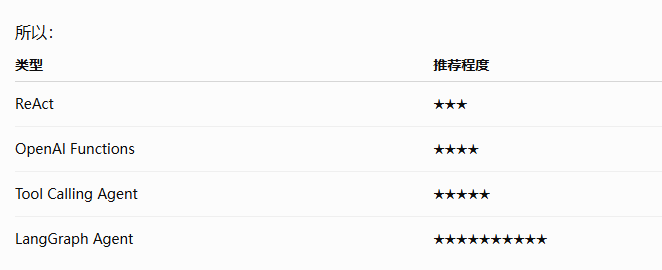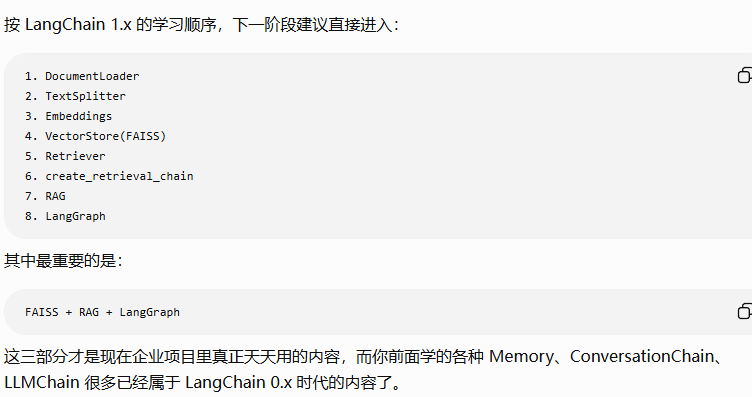

举例2：使用ChatPromptTemplate实现

In [4]:
from langchain.agents import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
# 获取Tavily搜索的实例
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType, create_tool_calling_agent, AgentExecutor
from langchain.tools import Tool
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
dotenv.load_dotenv()

# 读取配置文件的信息
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

# 获取Tavily搜索工具的实例
search = TavilySearchResults(max_results=3)

# 获取一个搜索的工具
# 使用Tool
search_tool = Tool(
    func=search.run,
    name="Search",
    description="用于检索互联网上的信息",
)


# 获取大语言模型
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    temperature=0,
)
# 提供提示词模板（以ChatPromptTemplate为例）
system_template = """
Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!"""

prompt_template = ChatPromptTemplate.from_messages([
    ("system",system_template),
    ("human","{input}"),
    ("system","{agent_scratchpad}"),
])

# 获取Agent的实例：create_react_agent()
agent = create_react_agent(
    llm=llm,
    prompt=prompt_template,
    tools=[search_tool]
)

# 获取AgentExecutor的实例
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True,
)


# 通过AgentExecutor的实例调用invoke(),得到响应
result = agent_executor.invoke({"input":"查询今天北京的天气情况"})

# 处理响应
print(result)


AIMessage(content='查询今天北京的天气情况：根据最新的天气预报，今天北京的天气建议您注意随时查看天气预报以获取最新的天气情况。', additional_kwargs={})


小结：

1、传统方式，相较于通用方式来讲，不用提供提示词模板。

2、对于通用方式来讲，

FUNCTION_CALL模式：在创建Agent时，推荐大家使用ChatPromptTemplate

ReAct模式：在创建Agent时，大家可以使用ChatPromptTemplate、PromptTemplate。但相较来讲，推荐大家使用PromptTemplate

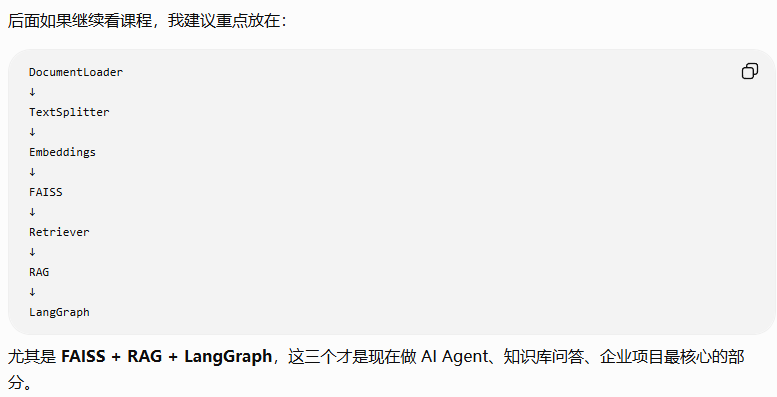